Predict the rent of the house from a given dataset. Perform following tasks:
1. Pre-process the dataset.
2. Identify outliers.
3. Check the correlation.
4. Implement random forest regression model.
5. Evaluate the models and compare their respective scores like R2, RMSE, etc.

Use : https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [32]:
data = pd.read_csv("D:/KAUSTUBH/LP3 Final/House_Rent_Dataset.csv")

print(data.head())

    Posted On  BHK   Rent  Size            Floor    Area Type  \
0  2022-05-18    2  10000  1100  Ground out of 2   Super Area   
1  2022-05-13    2  20000   800       1 out of 3   Super Area   
2  2022-05-16    2  17000  1000       1 out of 3   Super Area   
3  2022-07-04    2  10000   800       1 out of 2   Super Area   
4  2022-05-09    2   7500   850       1 out of 2  Carpet Area   

              Area Locality     City Furnishing Status  Tenant Preferred  \
0                    Bandel  Kolkata       Unfurnished  Bachelors/Family   
1  Phool Bagan, Kankurgachi  Kolkata    Semi-Furnished  Bachelors/Family   
2   Salt Lake City Sector 2  Kolkata    Semi-Furnished  Bachelors/Family   
3               Dumdum Park  Kolkata       Unfurnished  Bachelors/Family   
4             South Dum Dum  Kolkata       Unfurnished         Bachelors   

   Bathroom Point of Contact  
0         2    Contact Owner  
1         1    Contact Owner  
2         1    Contact Owner  
3         1    Contact Owner

In [33]:
# Pre-process dataset
data['Posted On'] = pd.to_datetime(data['Posted On'])
data['Posted Month'] = data['Posted On'].dt.month

In [34]:
# Handle 'Floor' column with additional non-numeric cases
def extract_floor_level(floor):
    try:
        if 'Ground' in floor:
            return 0
        elif 'Upper' in floor:
            return -1  # Using -1 for 'Upper' floors or any unknown case
        return int(floor.split(' ')[0])
    except ValueError:
        return -1  # For any other unexpected non-numeric entries

data['Floor Level'] = data['Floor'].apply(extract_floor_level)

In [35]:
# Encoding categorical variables
data['Area Type'] = data['Area Type'].map({'Super Area': 1, 'Carpet Area': 2, 'Built Area': 3})
data['Furnishing Status'] = data['Furnishing Status'].map({'Unfurnished': 0, 'Semi-Furnished': 1, 'Furnished': 2})
data['Tenant Preferred'] = data['Tenant Preferred'].map({'Bachelors': 1, 'Bachelors/Family': 2, 'Family': 3})
data['City'] = data['City'].factorize()[0]


In [36]:
data = data.drop(['Posted On', 'Point of Contact','Floor', 'Area Locality'], axis=1)

In [37]:
# Identify and remove outliers based on Rent and Size
data = data[(data['Rent'] < data['Rent'].quantile(0.99)) & (data['Size'] < data['Size'].quantile(0.99))]

### What is correlation matrix? What is heatmap? Use of correlation matrix and heatmap? How to read it?
### **Correlation Matrix**

A **correlation matrix** is a table that shows the correlation coefficients between many variables in a dataset. It helps to understand the relationships between different variables and how they vary with each other. 

- **Correlation Coefficient**: The correlation coefficient is a numerical value between -1 and 1 that indicates the strength and direction of a linear relationship between two variables. 
   - A **value of 1** indicates a perfect positive correlation (as one variable increases, the other also increases).
   - A **value of -1** indicates a perfect negative correlation (as one variable increases, the other decreases).
   - A **value of 0** indicates no linear correlation between the variables.

#### **Key Points of a Correlation Matrix**:
- Each cell in the matrix contains the correlation coefficient between two variables.
- The matrix is **symmetric**, meaning that the correlation between Variable A and Variable B is the same as between Variable B and Variable A.
- Diagonal values (correlation of a variable with itself) are always **1** because any variable is perfectly correlated with itself.

#### **Example of a Correlation Matrix**:
|          | Variable 1 | Variable 2 | Variable 3 |
|----------|------------|------------|------------|
| **Variable 1** | 1          | 0.8        | -0.4       |
| **Variable 2** | 0.8        | 1          | 0.3        |
| **Variable 3** | -0.4       | 0.3        | 1          |

- The correlation between Variable 1 and Variable 2 is **0.8**, meaning they have a strong positive correlation.
- The correlation between Variable 1 and Variable 3 is **-0.4**, showing a weak negative correlation.

---

### **Heatmap**
A **heatmap** is a graphical representation of data where individual values in a matrix are represented by different colors. In the context of a correlation matrix, a heatmap is used to visualize the correlation values in the matrix, with the colors indicating the strength and direction of the correlations.

#### **How a Heatmap Works**:
- **Color Coding**: The values in the correlation matrix are represented by a color gradient. Typically, the color scale goes from:
  - **Blue (or a cool color)** representing negative correlation (e.g., -1).
  - **Red (or a warm color)** representing positive correlation (e.g., +1).
  - **White or light colors** indicate a weak or no correlation (close to 0).
  
- The **brighter or darker** the color, the **stronger the correlation** (either positive or negative).

#### **Example Heatmap**:
Imagine we have a correlation matrix with three variables (Variable 1, Variable 2, and Variable 3). A heatmap could represent it like this:

```
        Variable 1    Variable 2    Variable 3
Variable 1   1           0.8          -0.4
Variable 2   0.8         1            0.3
Variable 3   -0.4        0.3          1
```

- **Dark Red (strong positive)**: Strong positive correlation (e.g., 0.8).
- **Dark Blue (strong negative)**: Strong negative correlation (e.g., -0.4).
- **Light or White**: No correlation (e.g., 0).

In the heatmap, **Variable 1** and **Variable 2** would be shaded in a darker red, indicating a strong positive correlation. **Variable 1** and **Variable 3** might be shaded in a darker blue, indicating a negative correlation.

### **Use of Correlation Matrix and Heatmap**
1. **Identifying Relationships Between Variables**:
   - A correlation matrix helps to understand how different variables in a dataset are related to each other. It helps in identifying both **positive** and **negative** relationships between features, which can be useful for feature selection, data cleaning, and understanding underlying patterns.

2. **Feature Selection**:
   - When building machine learning models, you can use the correlation matrix to identify and remove **highly correlated variables** (multicollinearity). Features that are strongly correlated with each other may lead to redundancy and can negatively affect model performance (e.g., in linear regression).

3. **Detecting Multicollinearity**:
   - If two or more variables have a very high positive correlation (e.g., >0.9), it indicates **multicollinearity**, which may cause instability in regression models. In such cases, one of the correlated features might be dropped to improve the model’s performance.

4. **Data Exploration**:
   - A heatmap provides a clear, visual way to understand relationships in large datasets, making it easier for data analysts to identify patterns, trends, and anomalies that might be harder to detect in raw numbers.

### **How to Read a Correlation Matrix and Heatmap**
1. **Identify the Strength of Correlation**:
   - A **correlation value** close to **+1** means a **strong positive correlation** (both variables increase together).
   - A **correlation value** close to **-1** means a **strong negative correlation** (as one variable increases, the other decreases).
   - A **correlation value** close to **0** means **no correlation** (the variables are unrelated).

2. **Interpret the Heatmap**:
   - **Red or warm colors** indicate a **strong positive correlation** (variables move in the same direction).
   - **Blue or cool colors** indicate a **strong negative correlation** (variables move in opposite directions).
   - **White or neutral colors** indicate **no or weak correlation** (variables are independent of each other).

3. **Diagonal Values**:
   - In the correlation matrix, **diagonal cells** will always have a value of **1**, as any variable is perfectly correlated with itself.

4. **Key Observations**:
   - Look for highly **positive correlations** to identify features that might share similar information.
   - Look for **negative correlations** to see features that move in opposite directions.
   - Look for **zero correlations** to identify independent variables, which might help in model building.

### **Example in Practice**:
Imagine you are working with a dataset of **customer data** with features like **age**, **income**, **education level**, and **spending score**. After creating a correlation matrix and heatmap, you might observe:

- **Age** and **income** have a strong positive correlation (+0.8), meaning older people tend to have higher incomes.
- **Age** and **spending score** have a negative correlation (-0.5), meaning older people tend to spend less, on average.
- **Income** and **education level** might have a moderate correlation, suggesting that higher-income individuals tend to have higher education levels.
- **Spending score** and **income** have no correlation, meaning spending is not strongly related to income in your dataset.

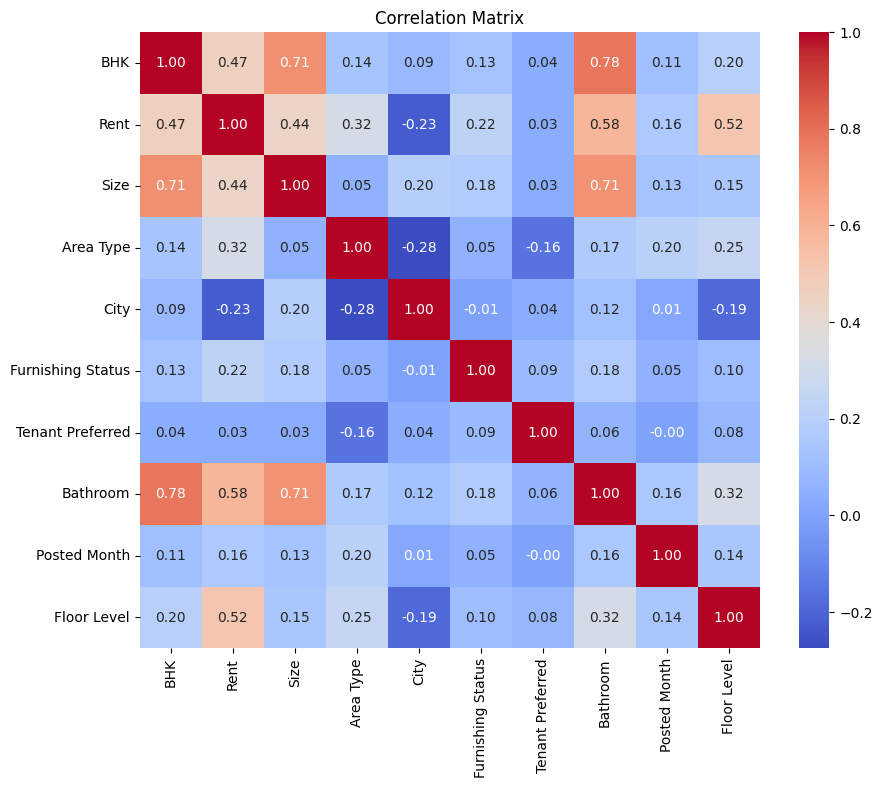

In [38]:
# Check correlation
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [39]:
# Prepare data for training
X = data.drop(['Rent'], axis=1)
y = data['Rent']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Random Forest:
Random Forest is an ensemble learning algorithm used for both classification and regression tasks. It is built by combining multiple decision trees to make predictions. The core idea is that by aggregating the predictions of many decision trees, the model's overall performance is improved, making it more accurate and robust compared to a single decision tree.

### Random Forest Regression

**Random Forest Regression** is a machine learning technique used to predict continuous numerical values. It is a variant of the **Random Forest** algorithm but tailored for **regression tasks** (predicting a continuous outcome, like house prices, temperature, etc.) rather than classification tasks (predicting categories like "spam" or "not spam").

Just like **Random Forest Classification**, Random Forest Regression builds an ensemble of decision trees and aggregates their predictions to make more accurate, stable, and reliable predictions. 

### How Random Forest Regression Works:
1. **Data Sampling** (Bootstrap Aggregating - Bagging):
   - A random sample of the data is taken with **replacement** to build each decision tree in the forest. This means some data points are used more than once, and some may be left out. This process helps in creating diverse trees and reducing overfitting.

2. **Feature Selection** (Random Feature Subsets):
   - For each decision tree, instead of considering all features (variables), **a random subset of features** is selected at each node (split) to find the best split. This further adds diversity to the trees and reduces correlation among them.

3. **Building Decision Trees**:
   - Each decision tree is trained on a different random subset of the data, and it predicts the target variable (the continuous value you are trying to predict) based on the data. These trees are typically **deep** (having many layers), and they perform well even when data has complex, non-linear relationships.

4. **Prediction Aggregation**:
   - **For Random Forest Regression**, after each tree makes its prediction (which is a single continuous value), the final prediction is obtained by taking the **average** of all the predictions from the individual trees.
   - This averaging process helps reduce the impact of outliers or noise and leads to a more accurate overall prediction.

### Key Steps in Random Forest Regression:
1. **Bootstrapping**: Random samples (with replacement) are taken from the training data to train each tree.
2. **Random Feature Selection**: Each tree makes decisions using a random subset of features.
3. **Prediction**: Once all the trees are built, their predictions are averaged to give the final result.

### Example:
Imagine you're using Random Forest Regression to predict **house prices** based on features like square footage, number of rooms, neighborhood, etc.

- **Step 1**: Randomly sample different subsets of the dataset to train multiple decision trees. Each tree may use different combinations of features (like one tree may focus on square footage and neighborhood, while another may use number of rooms and square footage).
- **Step 2**: Each tree independently makes a prediction of the house price based on the features it was trained on.
- **Step 3**: The Random Forest algorithm averages all the individual tree predictions to get the final predicted house price.

In [40]:
# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [41]:
# Evaluate model
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.7252686392906412
RMSE: 21290.457170113194
MAE: 10221.06993817723


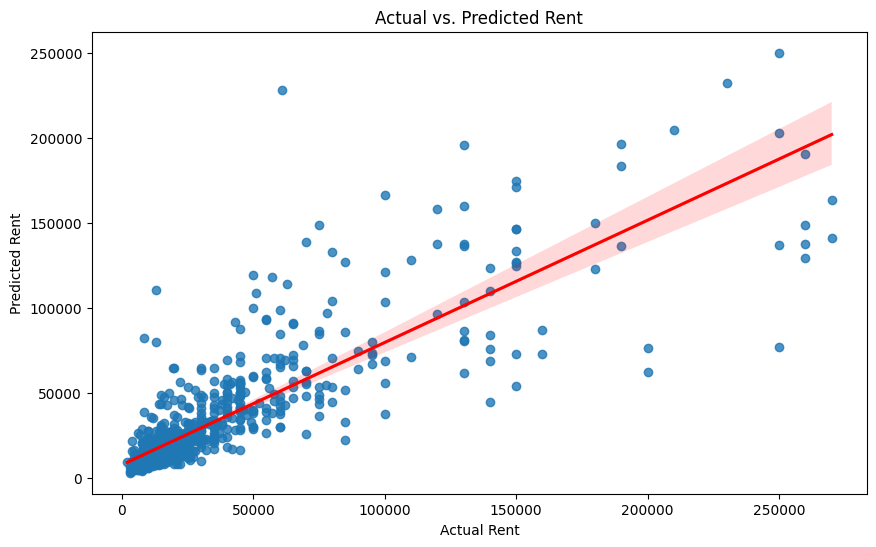

In [42]:
# Plot actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, line_kws={'color': 'red'})
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs. Predicted Rent")
plt.show()